<a href="https://colab.research.google.com/github/shivansh858/Text-to-image-using-Gen-Ai/blob/main/elevance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi


Fri Oct  2 11:04:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P0             29W /   70W |    7107MiB /  15360MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130


Looking in indexes: https://download.pytorch.org/whl/cu130


In [ ]:
import torch
x = torch.rand(5, 6)
print(x)

tensor([[0.9131, 0.4219, 0.5227, 0.8130, 0.4776, 0.0939],
        [0.1418, 0.5921, 0.7924, 0.2017, 0.7912, 0.2551],
        [0.0370, 0.7544, 0.2170, 0.6864, 0.8272, 0.2194],
        [0.7370, 0.6730, 0.0822, 0.0240, 0.5023, 0.1943],
        [0.7929, 0.9371, 0.0431, 0.4049, 0.4970, 0.7708]])


In [ ]:
!pip install diffusers transformers accelerate

In [ ]:
%%bash
!pip install gradio

In [5]:
import torch
import gradio as gr
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


In [3]:
from transformers import CLIPTokenizer

tokenizer = CLIPTokenizer.from_pretrained(
    model_id,
    subfolder="tokenizer",
    use_auth_token=True
)

text = "A beautiful red sun flower ."

tokens = tokenizer(
    text,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

print(tokens.input_ids.shape)

NameError: name 'model_id' is not defined

In [6]:
import gc
import torch
from diffusers import StableDiffusionXLPipeline
from diffusers import DiffusionPipeline
import torch

#this is taken from huggingface
model_id = 'stabilityai/stable-diffusion-xl-base-1.0'

#created a pipe line for generate the image
pipe = DiffusionPipeline.from_pretrained(model_id , torch_dtype=torch.float16, use_safetensors=True, variant="fp16")
#use cuda
pipe.to("cuda")


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.40.0",
  "_name_or_path": "stabilityai/stable-diffusion-xl-base-1.0",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [ ]:
from google.colab import drive


In [7]:
prompt='A futuristic smart city with flying cars, neon lights, cinematic atmosphere, highly detailed'
#this prompt is written for generate the imamge


In [8]:
#generate the image using by prompt
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


[prompt]: A futuristic smart city with flying cars, neon lights, cinematic atmosphere, highly detailed


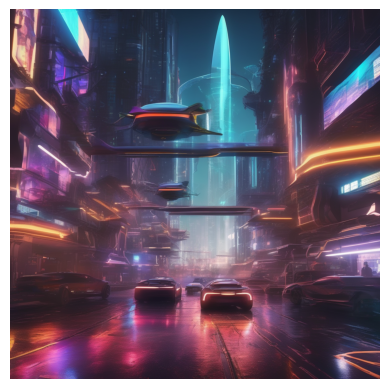

In [9]:
#final part, Just display the image
print('[prompt]:',prompt)
plt.axis('off');
plt.imshow(image);

In [10]:
import gradio as gr

def generate_image(prompt):
    if not prompt or not prompt.strip():
        return None

    result = pipe(
        prompt=prompt,
        num_inference_steps=30,
        guidance_scale=7.5
    )

    return result.images[0]


with gr.Blocks(title="Real-Time Text-to-Image Generator") as demo:

    gr.Markdown("""
    # 🎨 Real-Time Text-to-Image Generator

    ### Generative AI • Stable Diffusion • Hugging Face

    Enter a text prompt and generate an AI-created image.
    """)

    prompt = gr.Textbox(
        label="Text Prompt",
        placeholder="A girl sitting with her boyfriend and giving him a red flower",
        lines=3
    )

    generate_btn = gr.Button(
        "✨ Generate Image",
        variant="primary"
    )

    output = gr.Image(
        label="Generated Image",
        type="pil"
    )

    generate_btn.click(
        fn=generate_image,
        inputs=prompt,
        outputs=output
    )


demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0bb1c24b8abb7b852b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
